In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
df = sns.load_dataset("iris")

In [45]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [ ]:
# TOTAL RECORDS:
# The total number of flower samples available in the dataset.

In [46]:
#Total no of records
df.size

750

In [47]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [48]:
df.tail()


,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [49]:
df.size

750

In [50]:
df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [52]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [53]:
df.index

RangeIndex(start=0, stop=150, step=1)

In [54]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')

In [ ]:
# SPECIES DISTRIBUTION:
# The count and percentage of samples belonging to each iris species


In [55]:
unique = df["species"].unique()

In [56]:
unique

<StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str

In [57]:
#Total no of counts of each species
species = df["species"].value_counts()

In [58]:
species


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [59]:
percentage =  df["species"].value_counts(normalize = True) *100

In [60]:
percentage


species
setosa        33.333333
versicolor    33.333333
virginica     33.333333
Name: proportion, dtype: float64

In [66]:
result = pd.DataFrame({
    "Count":species,
    "Percentage":percentage,
})

result

,Count,Percentage
species,,
setosa,50,33.333333
versicolor,50,33.333333
virginica,50,33.333333


In [ ]:
# AVERAGE FEATURE VALUES BY SPECIES:
# Mean sepal length, sepal width, petal length, and petal width for each species.


In [62]:
avg_petal_length = df.groupby("species")["petal_length"].mean()

In [63]:
avg_petal_length

species
setosa        1.462
versicolor    4.260
virginica     5.552
Name: petal_length, dtype: float64

In [64]:
summary = df.groupby("species").agg(
    avg_petal_length = ("petal_length","mean"),
    avg_petal_width = ("petal_width","mean"),
    avg_sepal_length = ("sepal_length","mean"),
    avg_sepal_width = ("sepal_width","mean"),
)

In [65]:
summary

,avg_petal_length,avg_petal_width,avg_sepal_length,avg_sepal_width
species,,,,
setosa,1.462,0.246,5.006,3.428
versicolor,4.260,1.326,5.936,2.770
virginica,5.552,2.026,6.588,2.974


In [ ]:
# FEATURE CORRELATION MATRIX:
# To identify how features relate to each other (for example, correlation between petal length and petal width).


In [3]:
df = sns.load_dataset("iris")

In [5]:
corr_matrix = df.select_dtypes(include='number').corr()

In [6]:
corr_matrix

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


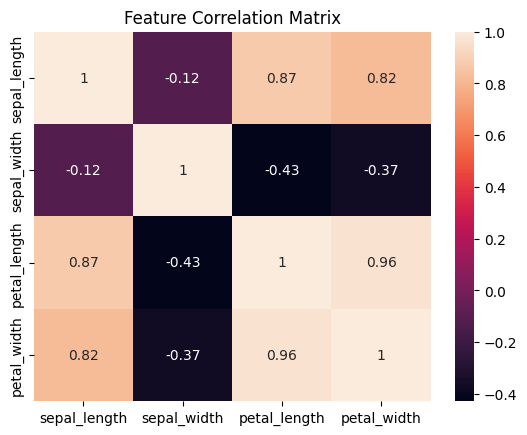

In [7]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
# OUTLIER DETECTION SUMMARY:
# Count and percentage of potential outliers across each numerical feature.


In [8]:
import pandas as pd

features = df.select_dtypes(include='number').columns

outlier_summary = []

for col in features:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    count = len(outliers)
    percent = (count / len(df)) * 100
    
    outlier_summary.append([col, count, percent])

outlier_df = pd.DataFrame(outlier_summary,
                          columns=["Feature","Outlier Count","Percentage"])

outlier_df

,Feature,Outlier Count,Percentage
0,sepal_length,0,0.000000
1,sepal_width,4,2.666667
2,petal_length,0,0.000000
3,petal_width,0,0.000000


In [ ]:
#Charts

# SPECIES DISTRIBUTION:
# Create a pie chart or bar chart showing the number of samples per iris species.



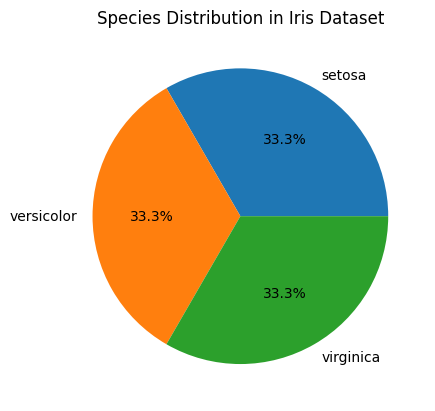

In [11]:
species_counts = df["species"].value_counts()

plt.pie(species_counts, labels=species_counts.index, autopct="%1.1f%%")

plt.title("Species Distribution in Iris Dataset")

plt.show()

In [12]:
# FEATURE COMPARISON BY SPECIES:
# Generate boxplots for each feature (sepal length, sepal width, petal length, petal width) grouped by species to analyze variation.


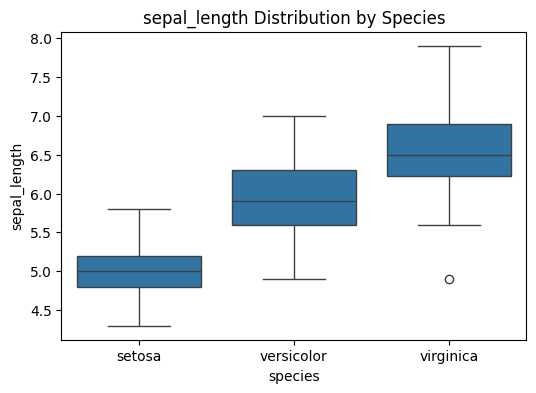

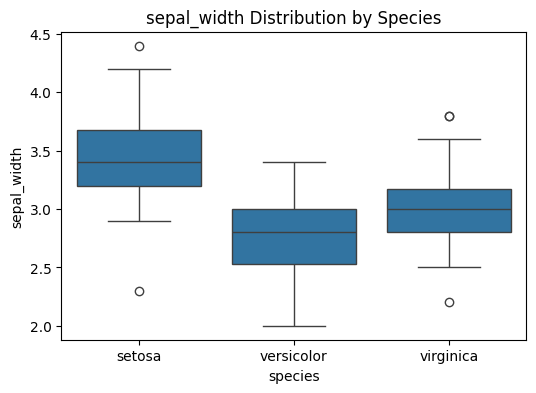

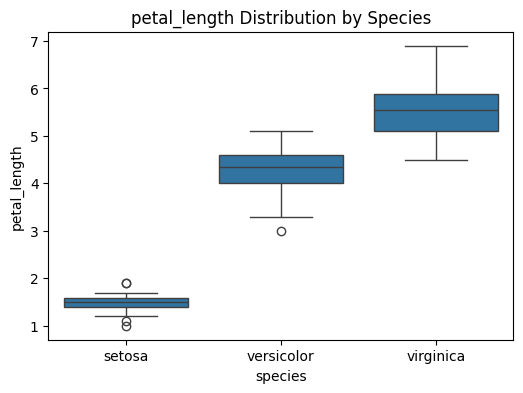

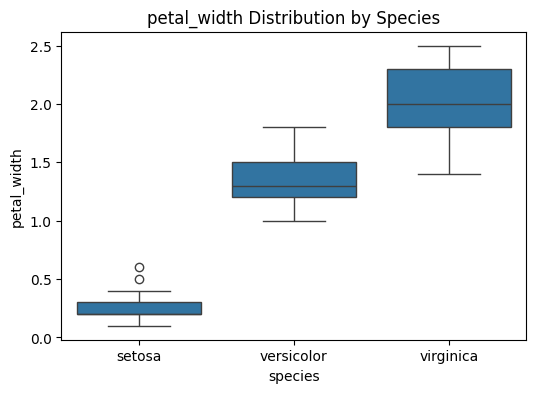

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

for feature in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="species", y=feature, data=df)
    plt.title(f"{feature} Distribution by Species")
    plt.show()

In [ ]:
# PAIR PLOT (SCATTER MATRIX):
# Create a scatter matrix to visualize the pairwise relationships among all numeric features colored by species.


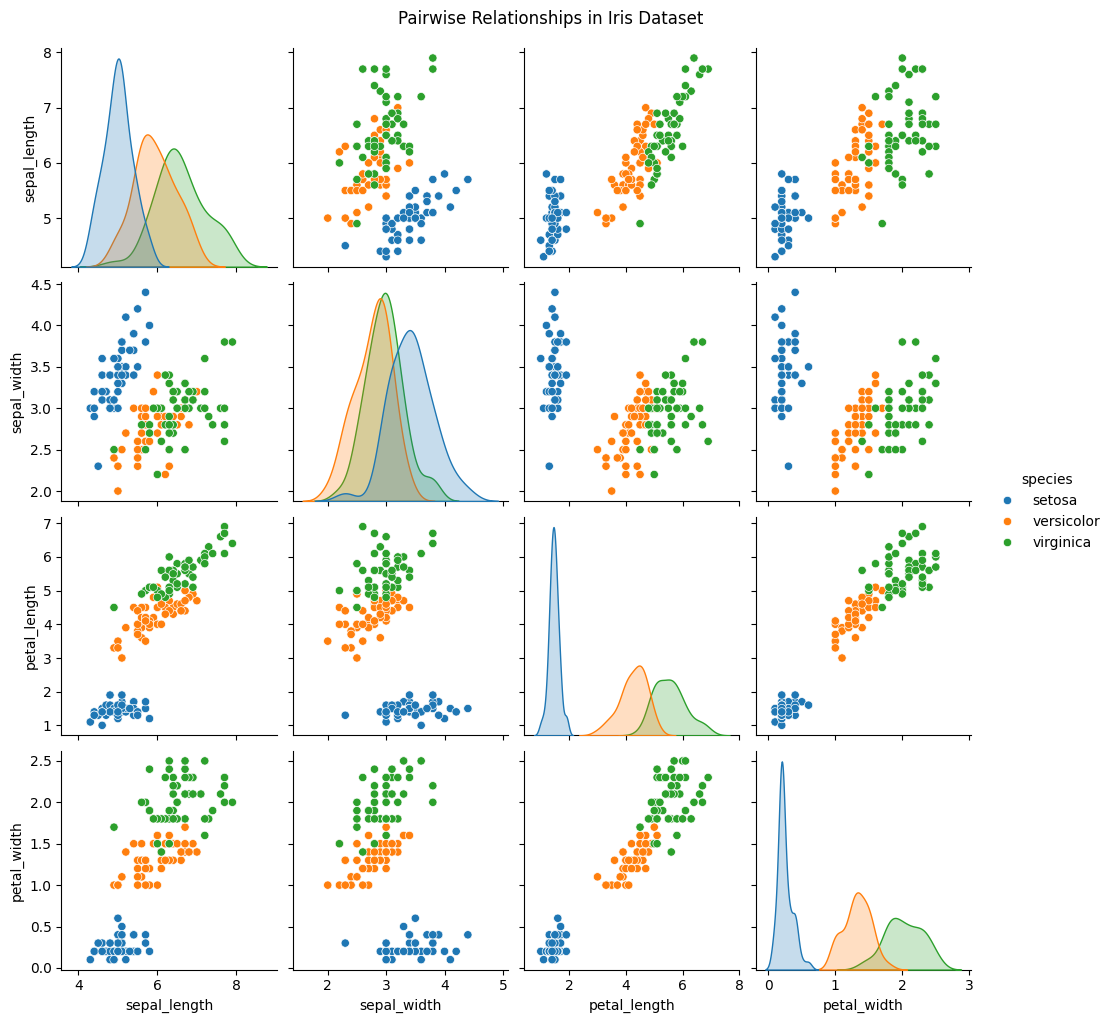

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue="species")

plt.suptitle("Pairwise Relationships in Iris Dataset", y=1.02)

plt.show()

In [ ]:
# CORRELATION HEATMAP:
# Visualize correlations among all numeric features to identify the most influential relationships.


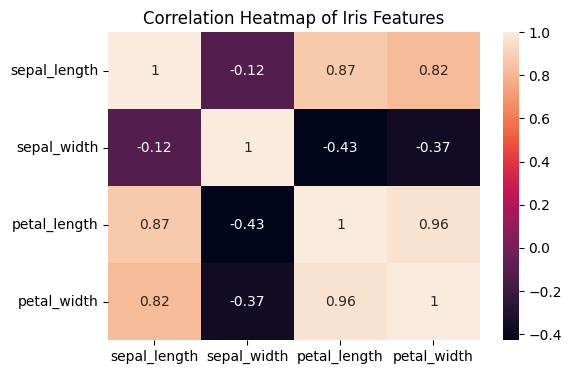

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.title("Correlation Heatmap of Iris Features")

plt.show()